In [54]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
import pooch
import scanpy as sc
import pandas as pd

In [55]:
sc.set_figure_params(dpi=50, facecolor="white")

In [56]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("./"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [57]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

In [58]:
adata.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1',
       ...
       'AC133551.1', 'AC136612.1', 'AC136616.1', 'AC136616.3', 'AC136616.2',
       'AC141272.1', 'AC023491.2', 'AC007325.1', 'AC007325.4', 'AC007325.2'],
      dtype='object', length=36601)

In [59]:
adata.obs

,sample
AAACCCAAGGATGGCT-1,s1d1
AAACCCAAGGCCTAGA-1,s1d1
AAACCCAAGTGAGTGC-1,s1d1
AAACCCACAAGAGGCT-1,s1d1
AAACCCACATCGTGGC-1,s1d1
...,...
TTTGTTGAGAGTCTGG-1,s1d3
TTTGTTGCAGACAATA-1,s1d3
TTTGTTGCATGTTACG-1,s1d3
TTTGTTGGTAGTCACT-1,s1d3


In [60]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [61]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

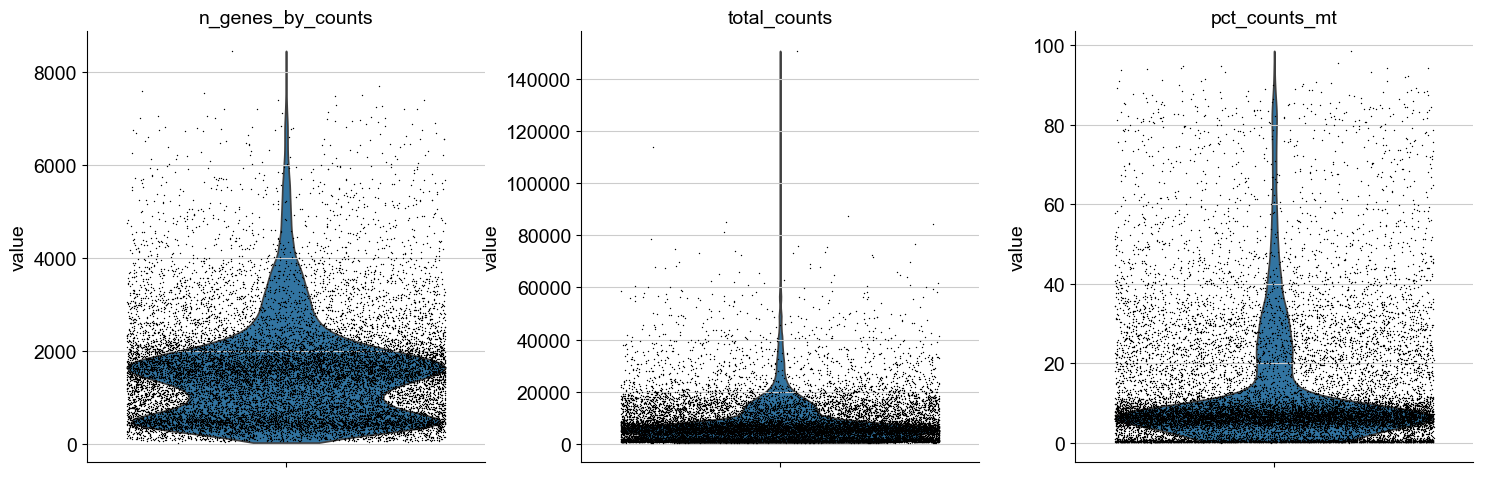

In [62]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

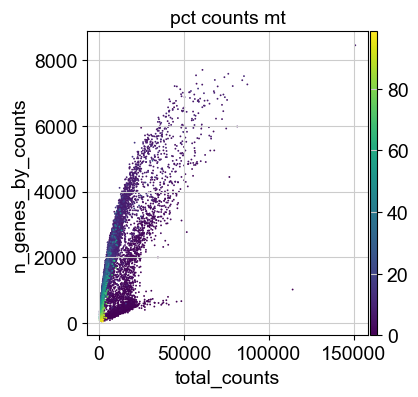

In [63]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [64]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [65]:
adata = adata[adata.obs.pct_counts_mt < 10, :]

In [66]:
adata

adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 21406024 stored elements and shape (11716, 23427)>

In [67]:
sc.pp.scrublet(adata, batch_key="sample")

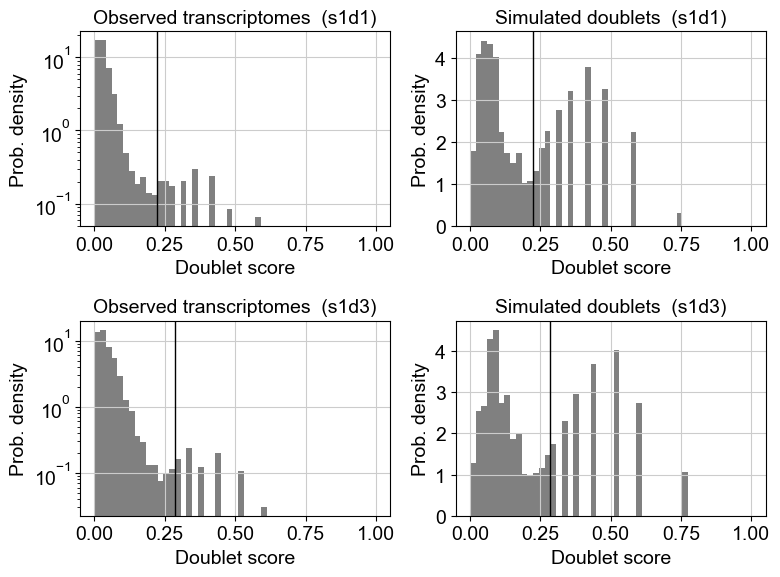

In [68]:
sc.pl.scrublet_score_distribution(adata)

In [69]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [70]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [71]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

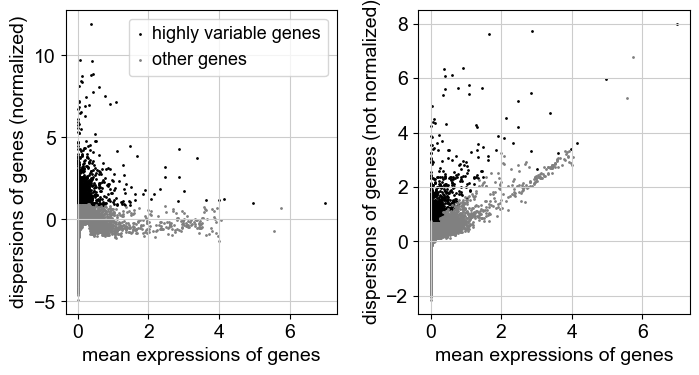

In [72]:
sc.pl.highly_variable_genes(adata)

In [73]:
sc.tl.pca(adata)

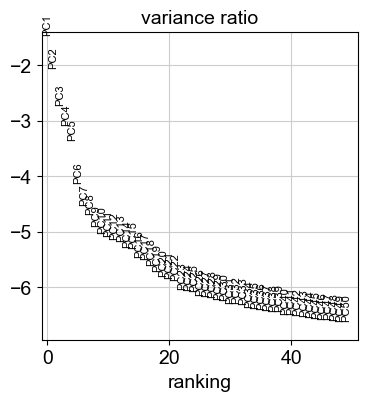

In [74]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

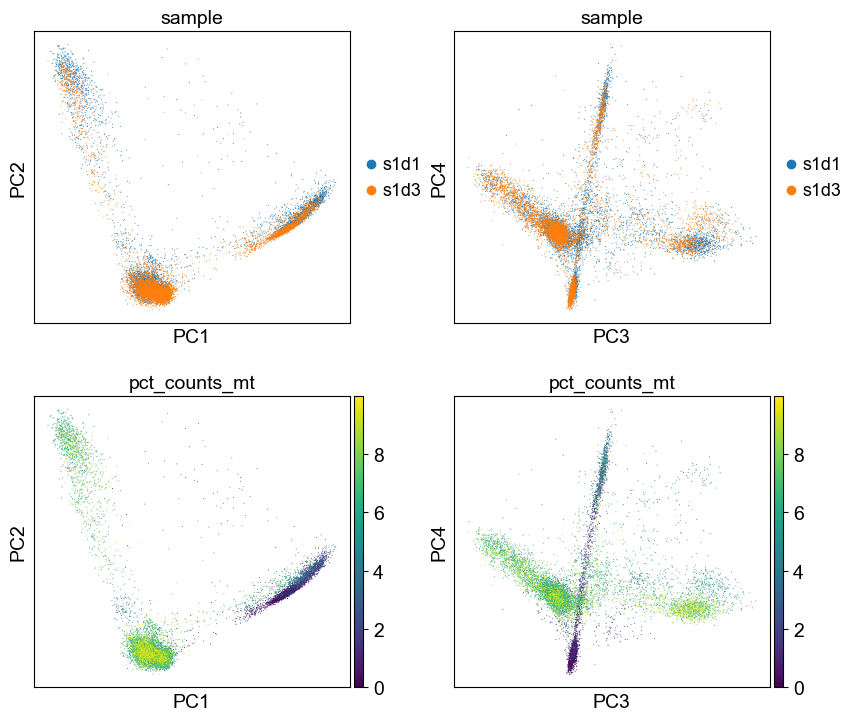

In [75]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [76]:
sc.pp.neighbors(adata)

In [77]:
sc.tl.umap(adata)

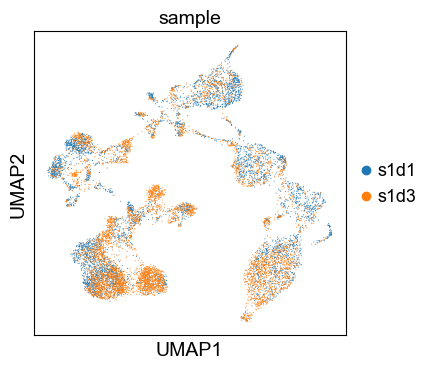

In [78]:
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [79]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

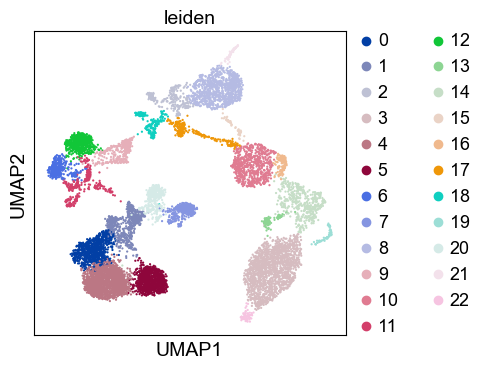

In [80]:
sc.pl.umap(adata, color=["leiden"])

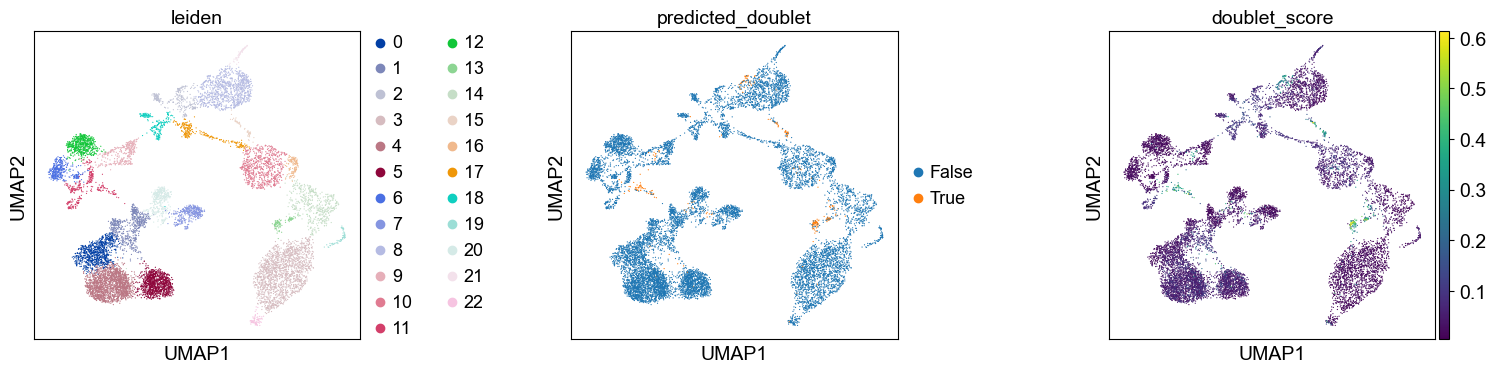

In [81]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

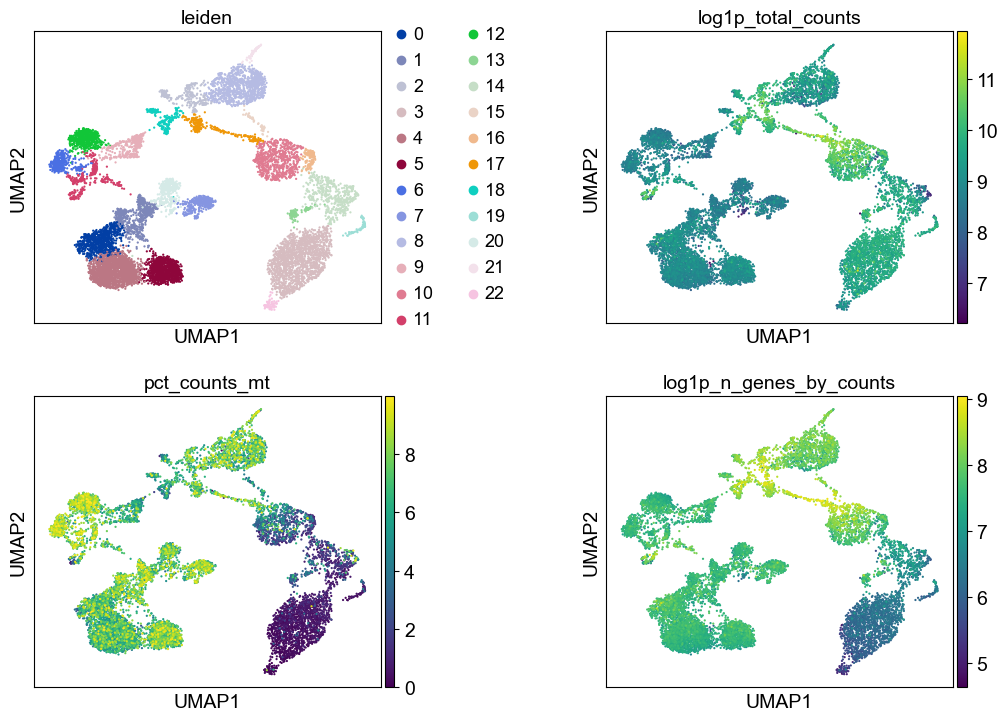

In [82]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

In [83]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

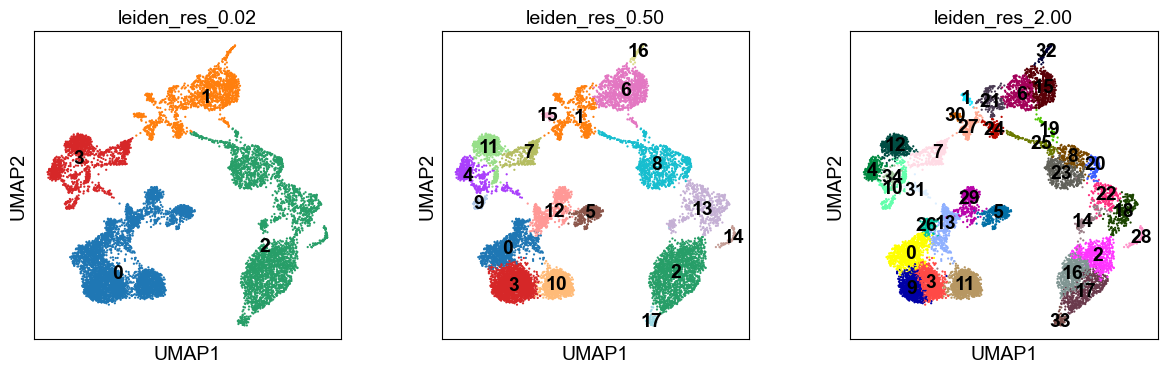

In [84]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

In [85]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

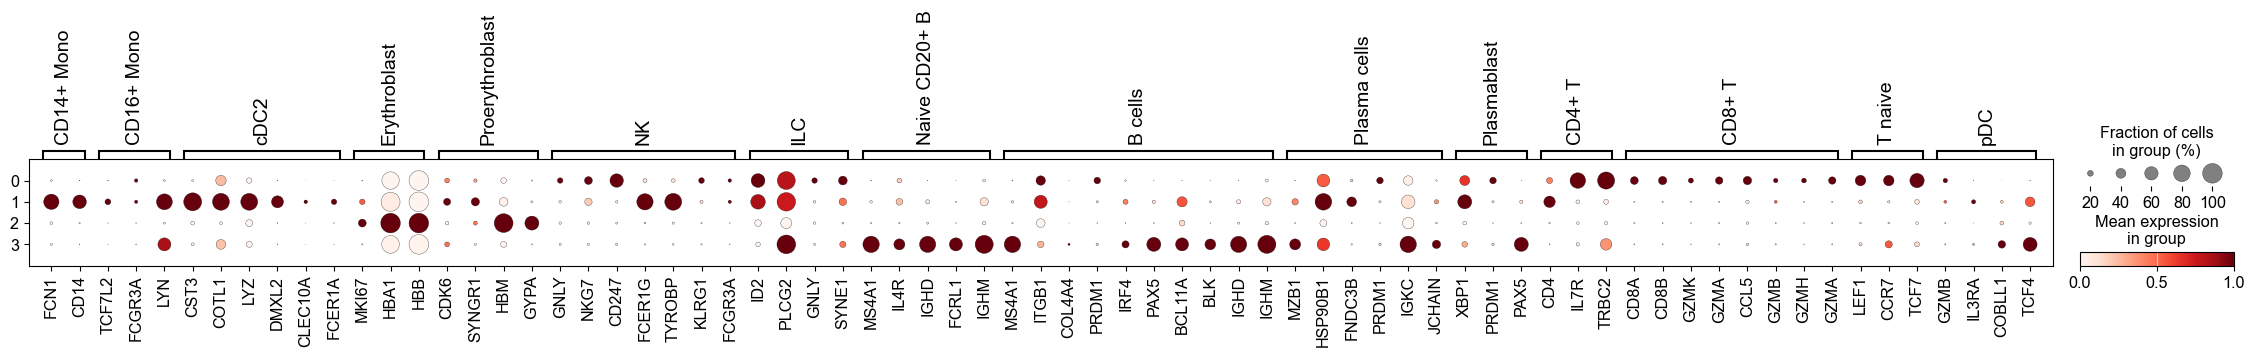

In [86]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.02", standard_scale="var")

In [87]:
adata.obs["cell_type_lvl1"] = adata.obs["leiden_res_0.02"].map(
    {
        "0": "CD4+T",
        "1": "cDC2",
        "2": "Erythroblast",
        "3": "B Cells",
    }
)

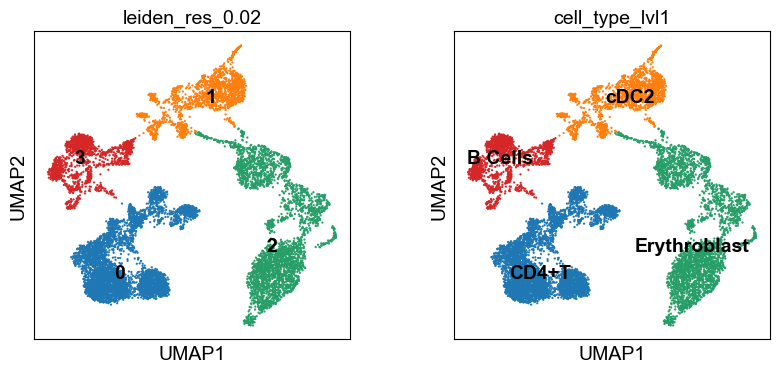

In [88]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "cell_type_lvl1"],
    legend_loc="on data",
)

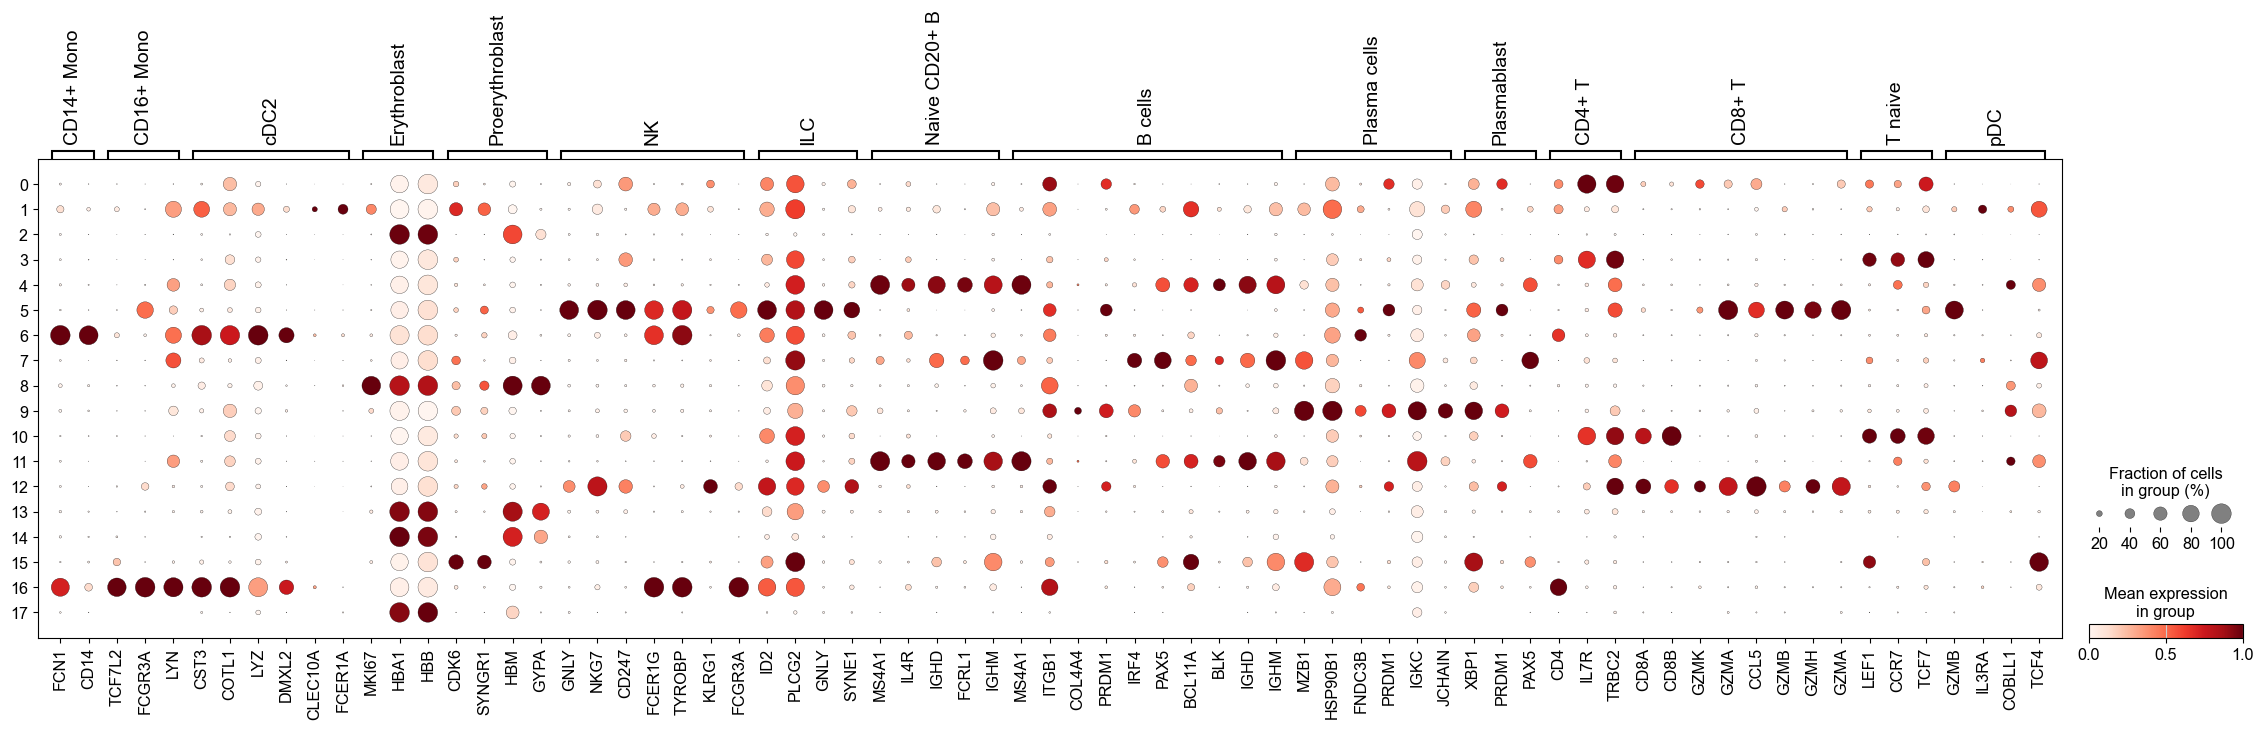

In [89]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.50", standard_scale="var")

In [90]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")

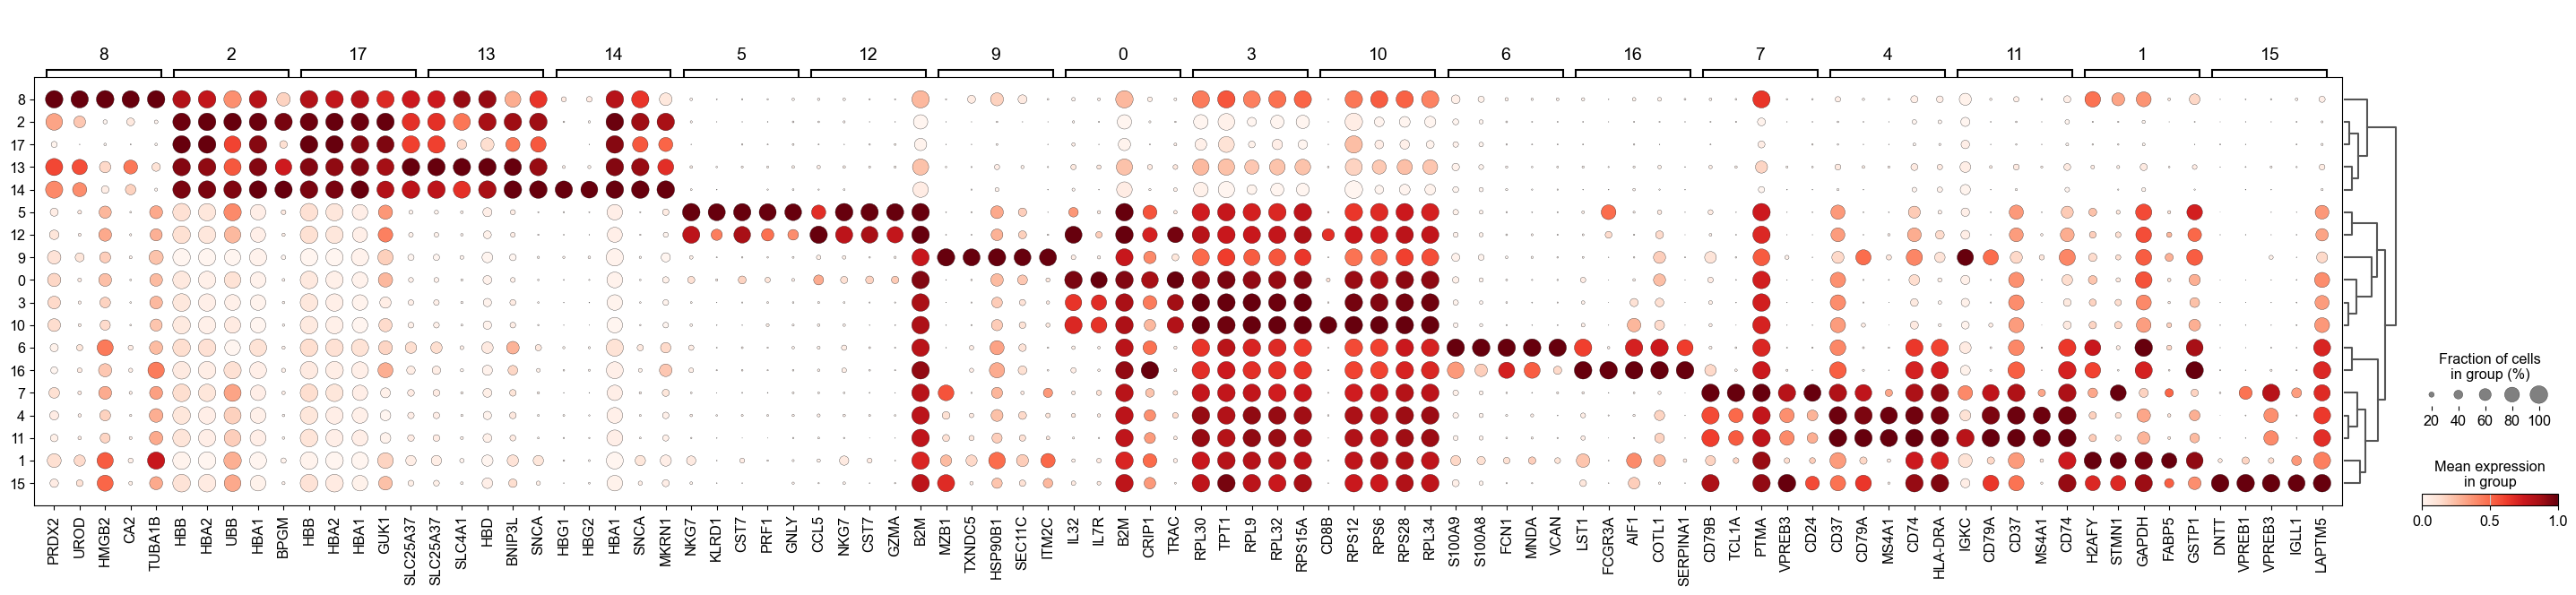

In [91]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_res_0.50", standard_scale="var", n_genes=5)

In [92]:
sc.get.rank_genes_groups_df(adata, group="7").head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CD79B,31.631578,5.977178,1.359075e-219,3.183906e-215
1,TCL1A,31.022215,6.416398,2.704704e-211,3.168155e-207
2,PTMA,30.274397,2.451758,2.491401e-201,1.945535e-197
3,VPREB3,30.241030,5.675845,6.845438e-201,4.009202e-197
4,CD24,30.006910,5.982350,7.974210e-198,3.736236e-194


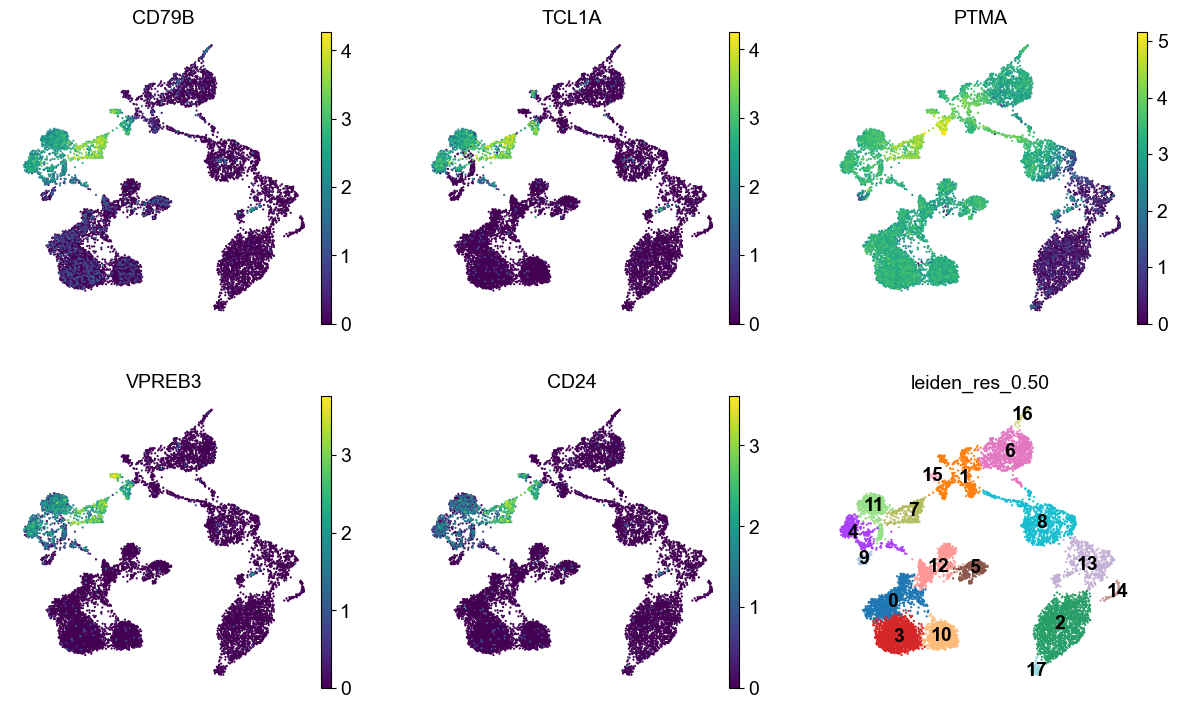

In [93]:
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="7").head(5)["names"]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)

In [94]:
adata.obs["cell_type_lvl2"] = adata.obs["leiden_res_0.50"].map(
    {
        "0": "T cells",
        "1": "cDC2",
        "2": "Macrophages",
        "3": "CD14+ Mono",
        "4": "CD16+ Mono",
        "5": "NK",
        "6": "ILC",
        "7": "B cells",
        "8": "Plasma cells",
        "9": "Proerythroblast",
        "10": "pDC",
        "11": "Plasmablast",
        "12": "Unknown",
        "13": "Unknown",
        "14": "Unknown",
        "15": "Unknown",
        "16": "Unknown",
        "17": "Unknown",
        "18": "Unknown"
    }
)

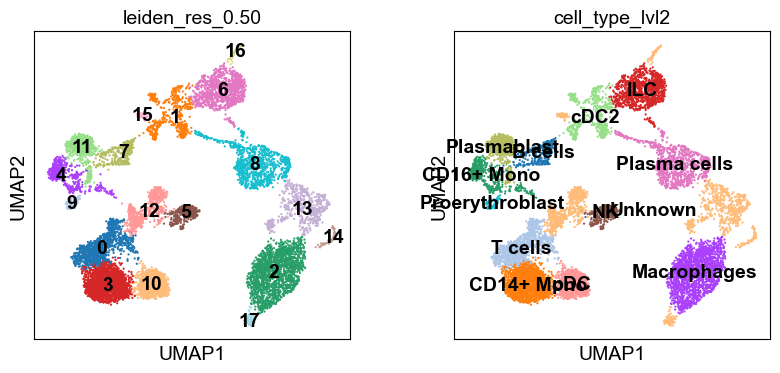

In [95]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.50", "cell_type_lvl2"],
    legend_loc="on data",
)

In [96]:
sc.get.rank_genes_groups_df(adata, group="1").head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,H2AFY,33.559708,3.053046,6.498111e-247,1.522312e-242
1,STMN1,31.397509,3.971544,2.188241e-216,2.563196e-212
2,GAPDH,30.528568,2.627173,1.088838e-204,8.502740e-201
3,FABP5,29.445906,3.719951,1.420501e-190,8.319519e-187
4,GSTP1,28.943600,2.597016,3.378269e-184,1.582854e-180
5,PPIA,28.923790,1.823120,5.996728e-184,2.341423e-180
6,VAMP8,28.644272,2.209368,1.889320e-180,6.323015e-177
7,SLC25A5,28.527853,2.211617,5.288900e-179,1.548788e-175
8,CCDC88A,28.119741,3.131936,5.620225e-174,1.316650e-170
9,ACTG1,28.082104,2.084072,1.620541e-173,3.451311e-170


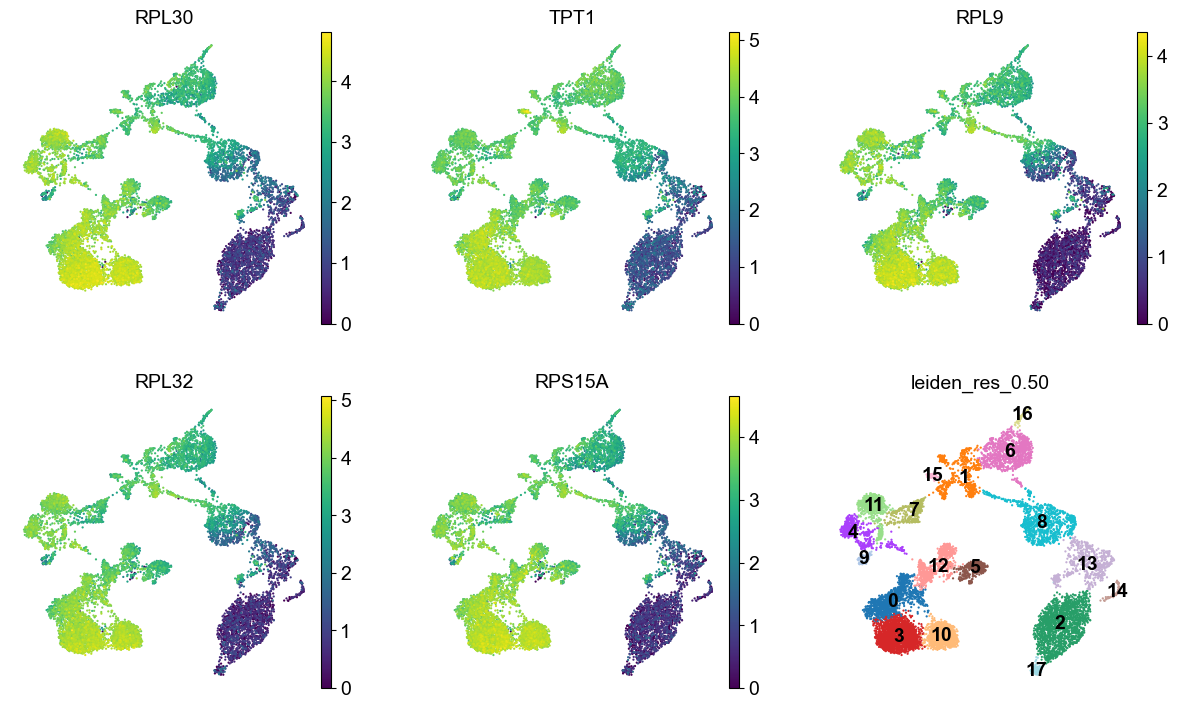

In [97]:
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="3").head(5)["names"]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)

In [98]:
# from cell_annotator import CellAnnotator

# cell_ann = CellAnnotator(
#     adata, species="human", tissue="bone marrow mononuclear cells", cluster_key="leiden_res_0.50", 
#     provider="gemini",
# ).annotate_clusters()

##get gemini api key from akshay and add in .env file and load it here

In [100]:
#using decoupler
import decoupler as dc

markers = dc.op.resource("PanglaoDB", organism="human")
markers

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
0,A1CF,False,Hepatocytes,Endoderm,True,0.189189,0.004437,True,0.175000,0.000257,9606,Liver,0.002
1,A2APA5,False,Germ cells,Mesoderm,False,0.000000,0.000000,True,0.432927,0.000000,10090,Reproductive,0.004
2,A2M,True,Bergmann glia,Ectoderm,True,0.000000,0.062343,True,0.333333,0.001604,9606,Brain,0.012
3,A3FIN4,False,Mast cells,Mesoderm,False,0.000000,0.000000,True,0.184211,0.000708,10090,Immune system,0.001
4,A4GALT,True,Mast cells,Mesoderm,True,0.000000,0.014133,True,0.000000,0.003023,9606,Immune system,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8206,ZNF521,False,Adipocyte progenitor cells,Mesoderm,True,0.000000,0.010338,False,0.000000,0.000000,9606,Connective tissue,0.002
8207,ZNRF4,False,Germ cells,Mesoderm,True,0.284360,0.000000,True,0.000000,0.000000,9606,Reproductive,0.010
8208,ZPBP2,True,Germ cells,Mesoderm,True,0.436019,0.000000,True,0.000000,0.000000,9606,Reproductive,0.008


In [101]:
# Filter by canonical_marker and human
markers = markers[
    markers["human"].astype(bool)
    & markers["canonical_marker"].astype(bool)
    & (markers["human_sensitivity"].astype(float) > 0.5)
]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]
markers

,source,target
,,
18,Pulmonary alveolar type II cells,ABCA3
90,Enterocytes,ACSL5
105,Smooth muscle cells,ACTA2
113,Smooth muscle cells,ACTG2
114,Myoepithelial cells,ACTG2
...,...,...
8092,Endothelial cells,VWF
8101,Luminal epithelial cells,WFDC2
8102,Ductal cells,WFDC2


In [102]:
dc.mt.ulm(data=adata, net=markers, tmin=3)

In [103]:
adata.obsm["score_ulm"]

,Acinar cells,Adipocytes,Alpha cells,Astrocytes,B cells,B cells naive,Basal cells,Beta cells,Cholangiocytes,Delta cells,...,Pancreatic stellate cells,Pericytes,Plasma cells,Plasmacytoid dendritic cells,Platelets,Podocytes,Proximal tubule cells,Pulmonary alveolar type II cells,Smooth muscle cells,T cells
AAACCCAAGGATGGCT-1,-0.983645,0.176561,1.151466,-0.777534,3.662724,5.359661,-0.425805,-0.737616,-0.650487,-0.425805,...,-0.337606,2.166592,1.137196,1.806679,5.251134,-1.099848,-0.886585,-0.737616,-0.737616,18.910591
AAACCCACAAGAGGCT-1,-1.414509,-0.653087,0.073371,-1.118107,8.884946,10.025091,-0.612309,-1.060704,-0.935408,1.230332,...,-1.224883,2.101079,8.450789,18.362708,5.132445,-0.737938,-1.000235,-0.486909,-0.156820,4.763549
AAACCCAGTCCGCAGT-1,0.677581,-0.332536,-0.235108,-0.303549,0.469093,0.663543,-0.166236,-0.287966,-0.253951,-0.166236,...,-0.332536,-0.235108,0.117081,-0.371810,2.519269,-0.429376,-0.346122,-0.287966,-0.287966,-0.384012
AAACGAAAGCAATTCC-1,-0.913776,-0.249521,0.669910,-0.722306,3.397160,5.017019,-0.395561,-0.685224,-0.604284,-0.395561,...,-0.791282,1.815765,1.330730,1.372733,3.732788,-1.021725,-0.823611,-0.685224,-0.685224,18.703793
AAACGAACAAGAATAC-1,-0.909775,0.519065,0.874018,-0.719143,23.519829,26.997213,-0.393829,-0.682224,-0.601638,-0.393829,...,-0.787817,2.054519,11.250745,3.518693,5.359102,-0.510996,-0.820004,-0.682224,-0.682224,8.846523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTCTCACAA-1,-0.642061,0.088408,-0.650038,-0.839272,-0.308483,-1.187182,-0.459615,-0.796185,-0.459044,-0.459615,...,-0.919419,-0.650038,-0.652569,-0.594569,2.279553,-0.715594,-0.956983,-0.796185,-0.796185,0.230809
TTTGGTTTCCGTCCTA-1,-0.932774,0.711395,0.751021,-0.737323,1.849240,4.181286,-0.403784,-0.699470,-0.616847,-0.403784,...,-0.807733,2.059027,-1.042967,1.509237,4.517718,-0.584525,-0.840734,-0.699470,-0.699470,14.147876
TTTGTTGCAGACAATA-1,-1.345150,-0.082787,1.010459,-0.668189,2.965190,0.662217,-0.582287,-1.008694,-0.889542,-0.582287,...,-1.164823,2.697831,1.989875,1.899522,7.209606,-0.279103,-0.519329,-1.008694,-0.083611,0.845982
TTTGTTGCATGTTACG-1,-0.626952,-0.116787,-0.622359,-0.803535,-0.530929,-0.943818,-0.440044,-0.762283,-0.672240,-0.440044,...,-0.880268,-0.622359,-0.439656,-0.761627,1.218859,-1.136628,-0.916233,-0.762283,-0.762283,0.124122


In [104]:
score = dc.pp.get_obsm(adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 11716 × 47
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.02', 'leiden_res_0.50', 'leiden_res_2.00', 'cell_type_lvl1', 'cell_type_lvl2'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'sample_colors', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'predicted_doublet_colors', 'leiden_res_0.02', 'leiden_res_0.50', 'leiden_res_2.00', 'leiden_res_0.02_colors', 'leiden_res_0.50_colors', 'leiden_res_2.00_colors', 'cell_type_lvl1_colors', 'rank_genes_groups', 'dendrogram_leiden_res_0.50', 'cell_type_lvl2_colors'
    obsm: 'X

In [105]:
score.obs.columns

Index(['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score',
       'predicted_doublet', 'leiden', 'leiden_res_0.02', 'leiden_res_0.50',
       'leiden_res_2.00', 'cell_type_lvl1', 'cell_type_lvl2'],
      dtype='object')

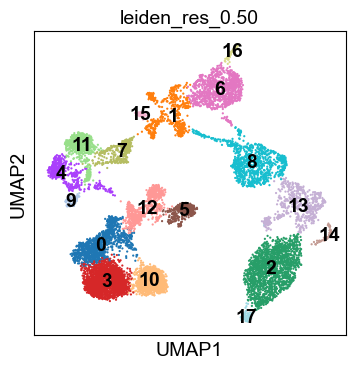

In [106]:
sc.pl.umap(score, color=["leiden_res_0.50"], legend_loc="on data")

In [107]:
df = dc.tl.rankby_group(adata=score, groupby="leiden_res_0.50", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,T cells,49.547528,10.522425,5.830665e-307,2.740413e-305
1,0,rest,Fibroblasts,23.845158,1.733321,1.022064e-108,2.401850e-107
2,0,rest,Platelets,22.358463,1.573668,6.072164e-99,9.513056e-98
3,0,rest,Pericytes,21.940306,0.948488,1.262792e-95,1.483781e-94
5,0,rest,Ductal cells,20.025344,0.692559,8.217818e-82,6.437291e-81
...,...,...,...,...,...,...,...
836,17,rest,Hepatocytes,2.598426,0.156369,1.117155e-02,1.381744e-02
837,17,rest,Loop of Henle cells,2.483176,0.217385,1.419148e-02,1.710256e-02
841,17,rest,Oligodendrocytes,1.725419,0.170398,8.645243e-02,9.449452e-02
843,17,rest,Delta cells,1.464167,0.079863,1.471331e-01,1.536723e-01


In [108]:
n_ctypes = 3
ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
ctypes_dict

/var/folders/yp/rq67n9wd35vfkdbx07pvj2k80000gp/T/ipykernel_50409/777748877.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = df.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


{'0': ['T cells', 'Fibroblasts', 'Platelets'],
 '1': ['Pericytes', 'Hepatic stellate cells', 'Fibroblasts'],
 '10': ['T cells', 'Pericytes', 'Neurons'],
 '11': ['B cells naive', 'B cells', 'Plasma cells'],
 '12': ['NK cells', 'Gamma delta T cells', 'Platelets'],
 '13': ['Erythroid-like and erythroid precursor cells',
  'Enterocytes',
  'Acinar cells'],
 '14': ['Erythroid-like and erythroid precursor cells',
  'Enteroendocrine cells',
  'Enterocytes'],
 '15': ['Endothelial cells', 'B cells', 'Mesangial cells'],
 '16': ['Hepatocytes', 'Macrophages', 'Dendritic cells'],
 '17': ['Enteroendocrine cells',
  'Erythroid-like and erythroid precursor cells',
  'Pancreatic stellate cells'],
 '2': ['Erythroid-like and erythroid precursor cells',
  'Enteroendocrine cells',
  'Basal cells'],
 '3': ['T cells', 'Pericytes', 'Neurons'],
 '4': ['B cells', 'B cells naive', 'Plasma cells'],
 '5': ['Gamma delta T cells', 'NK cells', 'Beta cells'],
 '6': ['Neutrophils', 'Monocytes', 'Macrophages'],
 '7': ['

categories: 0, 1, 2, etc.
var_group_labels: 0, 1, 10, etc.


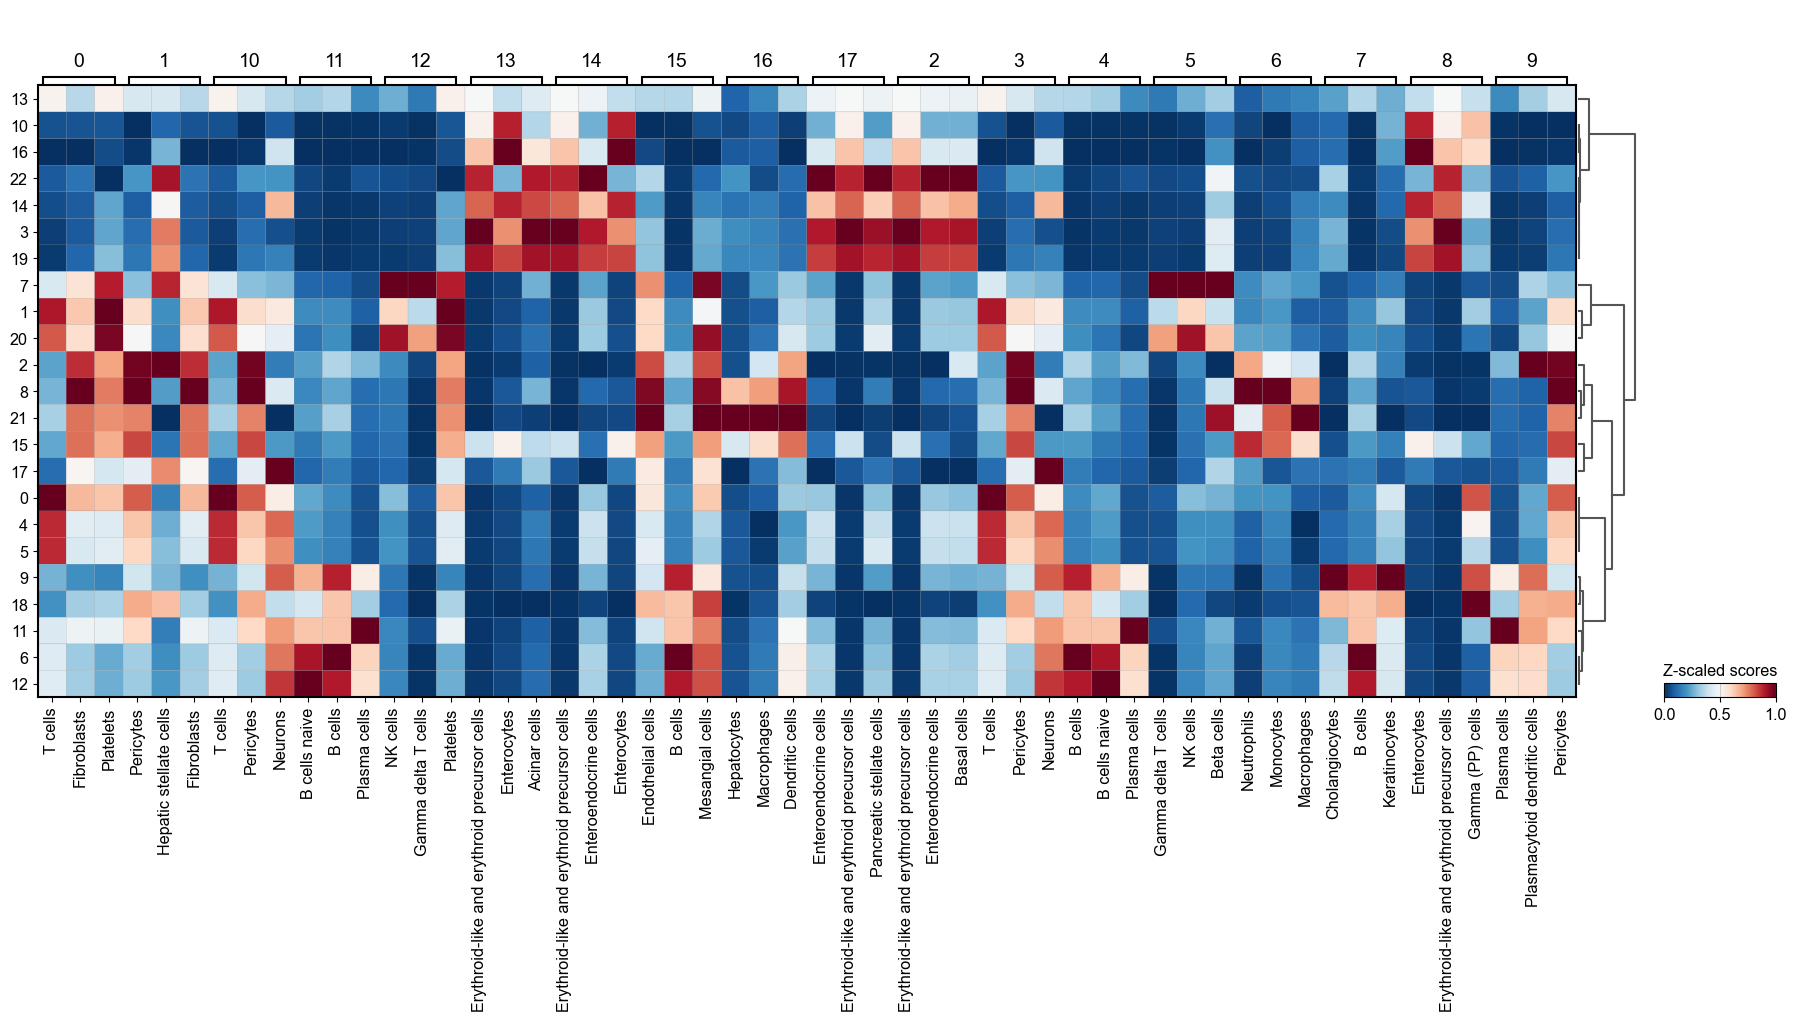

In [109]:
sc.pl.matrixplot(
    adata=score,
    var_names=ctypes_dict,
    groupby="leiden",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

2026-03-06 18:40:02 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-06 18:40:02 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-06 18:40:02 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-06 18:40:02 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-06 18:40:02 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

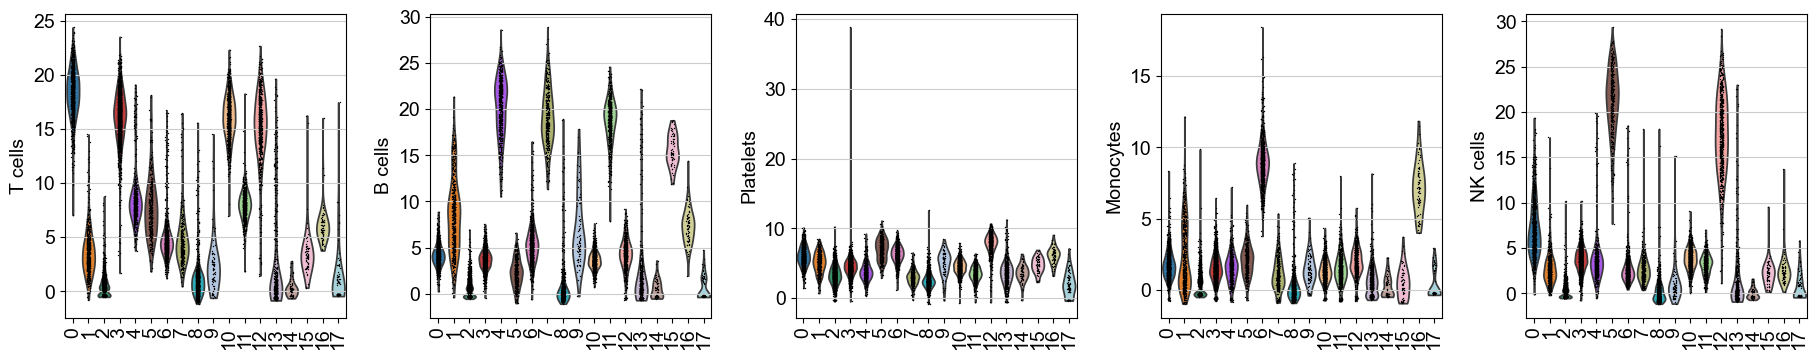

In [110]:
sc.pl.violin(
    adata=score,
    keys=["T cells", "B cells", "Platelets", "Monocytes", "NK cells"],
    groupby="leiden_res_0.50",
    rotation=90,
)

In [111]:
dict_ann = df[df["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
dict_ann

/var/folders/yp/rq67n9wd35vfkdbx07pvj2k80000gp/T/ipykernel_50409/1491444522.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dict_ann = df[df["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


{'0': 'T cells',
 '1': 'Pericytes',
 '2': 'Erythroid-like and erythroid precursor cells',
 '3': 'T cells',
 '4': 'B cells',
 '5': 'Gamma delta T cells',
 '6': 'Neutrophils',
 '7': 'Cholangiocytes',
 '8': 'Enterocytes',
 '9': 'Plasma cells',
 '10': 'T cells',
 '11': 'B cells naive',
 '12': 'NK cells',
 '13': 'Erythroid-like and erythroid precursor cells',
 '14': 'Erythroid-like and erythroid precursor cells',
 '15': 'Endothelial cells',
 '16': 'Hepatocytes',
 '17': 'Enteroendocrine cells'}

In [112]:
from collections import defaultdict

celltype_clusters = defaultdict(list)

for cluster, celltype in dict_ann.items():
    celltype_clusters[celltype].append(cluster)

dict(celltype_clusters)

{'T cells': ['0', '3', '10'],
 'Pericytes': ['1'],
 'Erythroid-like and erythroid precursor cells': ['2', '13', '14'],
 'B cells': ['4'],
 'Gamma delta T cells': ['5'],
 'Neutrophils': ['6'],
 'Cholangiocytes': ['7'],
 'Enterocytes': ['8'],
 'Plasma cells': ['9'],
 'B cells naive': ['11'],
 'NK cells': ['12'],
 'Endothelial cells': ['15'],
 'Hepatocytes': ['16'],
 'Enteroendocrine cells': ['17']}

In [113]:
cluster_to_celltype = dict_ann
score.obs["cell_type"] = score.obs["leiden_res_0.50"].map(cluster_to_celltype)

... storing 'cell_type' as categorical


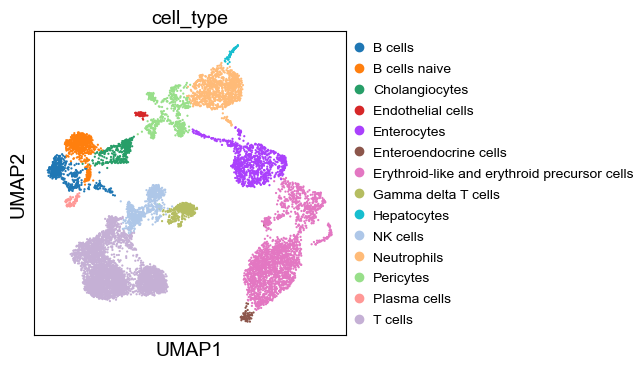

In [114]:
sc.pl.umap(score, color="cell_type")#, legend_loc="on data")

In [115]:
unique_dict = {}
for k, v in dict_ann.items():
    if v not in unique_dict.values():
        unique_dict[k] = v

unique_dict

{'0': 'T cells',
 '1': 'Pericytes',
 '2': 'Erythroid-like and erythroid precursor cells',
 '4': 'B cells',
 '5': 'Gamma delta T cells',
 '6': 'Neutrophils',
 '7': 'Cholangiocytes',
 '8': 'Enterocytes',
 '9': 'Plasma cells',
 '11': 'B cells naive',
 '12': 'NK cells',
 '15': 'Endothelial cells',
 '16': 'Hepatocytes',
 '17': 'Enteroendocrine cells'}

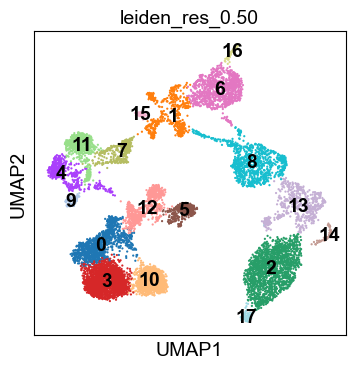

In [116]:
sc.pl.umap(
    adata=adata,
    color=["leiden_res_0.50"],
    ncols=1,
    legend_loc="on data",
)

In [118]:
import celltypist
from celltypist import models
import scvi

/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
/Users/varunshamanna/miniconda3/envs/scrna/lib/python3.13/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)


In [119]:
models.get_all_models()

['Lethal_COVID19_Lung.pkl',
 'Cells_Human_Tonsil.pkl',
 'Fetal_Human_Pancreas.pkl',
 'Human_Longitudinal_Hippocampus.pkl',
 'Human_IPF_Lung.pkl',
 'Adult_cHSPCs_Illumina.pkl',
 'Human_Lung_Atlas.pkl',
 'Mouse_Isocortex_Hippocampus.pkl',
 'Developing_Mouse_Brain.pkl',
 'Adult_Human_Skin.pkl',
 'Immune_All_High.pkl',
 'Mouse_Postnatal_DentateGyrus.pkl',
 'Adult_Human_PrefrontalCortex.pkl',
 'Cells_Lung_Airway.pkl',
 'Nuclei_Human_InnerEar.pkl',
 'Developing_Human_Brain.pkl',
 'Cells_Fetal_Lung.pkl',
 'Developing_Human_Organs.pkl',
 'Human_Endometrium_Atlas.pkl',
 'Adult_Human_Vascular.pkl',
 'Cells_Intestinal_Tract.pkl',
 'Developing_Human_Gonads.pkl',
 'Human_Embryonic_YolkSac.pkl',
 'Mouse_Dendritic_Subtypes.pkl',
 'Developing_Human_Thymus.pkl',
 'Fetal_Human_Pituitary.pkl',
 'Adult_cHSPCs_Ultima.pkl',
 'Adult_Human_PancreaticIslet.pkl',
 'Developing_Human_Hippocampus.pkl',
 'Human_Placenta_Decidua.pkl',
 'Human_Developmental_Retina.pkl',
 'Adult_Mouse_Gut.pkl',
 'Healthy_Mouse_Liver.p

In [126]:
import os

rdatas = []
for dem in [x for x in os.listdir('./ref_1/GSE116256_RAW') if 'dem' in x]:
    basename = dem.split('.')[0]
    samp = basename.split('_')[1]
    anno = [x for x in os.listdir('./ref_1/GSE116256_RAW/') if samp == x.split('_')[1].split('.')[0] and 'anno' in x][0]

    temp_data = sc.read_text('./ref_1/GSE116256_RAW/' + dem).T
    temp_anno = pd.read_table('./ref_1/GSE116256_RAW/' + anno, index_col=0)[['CellType']]
    temp_data.obs = temp_data.obs.merge(right = temp_anno, left_index=True, right_index=True)

    temp_data.obs['ID'] = basename
    rdatas.append(temp_data)

In [127]:
rdata = sc.concat(rdatas)

In [128]:
rdata.obs.groupby('CellType').size()

CellType
B                520
CTL             1338
GMP              918
GMP-like        3055
HSC             1709
HSC-like        1979
Mono            2758
Mono-like       2655
NK              1969
Plasma          1146
ProB             298
ProMono         1146
ProMono-like    1917
Prog            1709
Prog-like       4438
T               7105
cDC              849
cDC-like        2125
earlyEry        1119
lateEry         1329
pDC              225
dtype: int64

In [129]:
sc.pp.filter_genes(rdata, min_cells = 10)

In [130]:
sc.pp.normalize_total(rdata, target_sum = 1e4) #Note this is only for cell annotation, recommended by authors but not best
sc.pp.log1p(rdata)

In [131]:
rdata.obs

,CellType,ID
OCI-AML3_AAAAAGTATGGG,ProMono-like,GSM3588005_OCI-AML3
OCI-AML3_AAAAGACGACGG,GMP-like,GSM3588005_OCI-AML3
OCI-AML3_AAAATCTTTCCT,GMP-like,GSM3588005_OCI-AML3
OCI-AML3_AAAATGCATTTN,Prog-like,GSM3588005_OCI-AML3
OCI-AML3_AAAATTTTCCGC,GMP-like,GSM3588005_OCI-AML3
...,...,...
AML420B-D35_TACTCAAAGGTN,T,GSM3587957_AML420B-D35
AML420B-D35_TATATATAGCGT,Mono,GSM3587957_AML420B-D35
AML420B-D35_TGGCCCAGCAGN,T,GSM3587957_AML420B-D35
AML420B-D35_TGTTTTAGCAAG,T,GSM3587957_AML420B-D35


In [132]:
rdata = rdata[~rdata.obs.CellType.isna()]

In [133]:
rdata

View of AnnData object with n_obs × n_vars = 40307 × 19616
    obs: 'CellType', 'ID'
    var: 'n_cells'
    uns: 'log1p'

In [135]:
ref_model = celltypist.train(rdata, labels = 'CellType', n_jobs = 8,
                            use_SGD = False,
                            feature_selection = True, top_genes = 300)

2026-03-06 19:18:39 | [INFO] 🍳 Preparing data before training
2026-03-06 19:18:40 | [INFO] 🔬 Input data has 40307 cells and 19616 genes
2026-03-06 19:18:40 | [INFO] ⚖️ Scaling input data
2026-03-06 19:18:46 | [INFO] 🏋️ Training data using SGD logistic regression
2026-03-06 19:27:22 | [INFO] 🔎 Selecting features
2026-03-06 19:27:22 | [INFO] 🧬 2472 features are selected
2026-03-06 19:27:22 | [INFO] 🏋️ Starting the second round of training
2026-03-06 19:27:22 | [INFO] 🏋️ Training data using logistic regression


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:
ref_model.write('/home/varunshamanna/.celltypist/data/models/ref.pkl')

In [ ]:
model_low = models.Model.load(model="Immune_All_Low.pkl")
ref_model = models.Model.load(model="ref.pkl")

In [141]:
def predict_cells(adata):
    sc.pp.filter_genes(adata, min_cells = 10)
    sc.pp.normalize_total(adata, target_sum=1e4) #not recommended for typical pp
    sc.pp.log1p(adata)

    if issparse(adata.X):
        adata.X = adata.X.toarray()

    predictions = celltypist.annotate(adata, model=model_low, majority_voting=False)
    predictions_adata = predictions.to_adata()
    adata.obs["low_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
    adata.obs["low_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

    # predictions = celltypist.annotate(adata, model=ref_model, majority_voting=False)
    # predictions_adata = predictions.to_adata()
    # adata.obs["ref_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
    # adata.obs["ref_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

    return adata.obs

In [142]:
from scipy.sparse import issparse
import numpy

predictions = predict_cells(adata)

2026-03-06 19:34:11 | [INFO] 🔬 Input data has 11716 cells and 19219 genes
2026-03-06 19:34:11 | [INFO] 🔗 Matching reference genes in the model
2026-03-06 19:34:12 | [INFO] 🧬 5579 features used for prediction
2026-03-06 19:34:12 | [INFO] ⚖️ Scaling input data
2026-03-06 19:34:13 | [INFO] 🖋️ Predicting labels
2026-03-06 19:34:13 | [INFO] ✅ Prediction done!


In [143]:
predictions = predictions[['low_label', 'low_score']] #, 'ref_label', 'ref_score'
predictions

,low_label,low_score
AAACCCAAGGATGGCT-1,Tem/Effector helper T cells,0.276448
AAACCCACAAGAGGCT-1,pDC,0.999709
AAACCCAGTCCGCAGT-1,Late erythroid,0.509364
AAACGAAAGCAATTCC-1,Tcm/Naive helper T cells,0.252508
AAACGAACAAGAATAC-1,Naive B cells,0.999721
...,...,...
TTTGGTTGTCTCACAA-1,Mid erythroid,0.998902
TTTGGTTTCCGTCCTA-1,Tcm/Naive helper T cells,0.336240
TTTGTTGCAGACAATA-1,GMP,0.008620
TTTGTTGCATGTTACG-1,Mid erythroid,0.995287


In [144]:
predictions.to_csv('PREDICTIONS.csv')

In [145]:
adata

AnnData object with n_obs × n_vars = 11716 × 19219
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.02', 'leiden_res_0.50', 'leiden_res_2.00', 'cell_type_lvl1', 'cell_type_lvl2', 'predicted_labels', 'conf_score', 'low_label', 'low_score'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'scrublet', 'log1p', 'hvg', 'p

In [146]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,leiden,leiden_res_0.02,leiden_res_0.50,leiden_res_2.00,cell_type_lvl1,cell_type_lvl2,predicted_labels,conf_score,low_label,low_score
AAACCCAAGGATGGCT-1,s1d1,2103,7.651596,8663.0,9.066932,42.721921,59.667552,69.744892,79.348955,460.0,...,0,0,0,0,CD4+T,T cells,Tem/Effector helper T cells,0.276448,Tem/Effector helper T cells,0.276448
AAACCCACAAGAGGCT-1,s1d1,4330,8.373554,17345.0,9.761117,27.662150,38.420294,48.901701,62.023638,780.0,...,2,1,1,1,cDC2,cDC2,pDC,0.999709,pDC,0.999709
AAACCCAGTCCGCAGT-1,s1d1,468,6.150603,17290.0,9.757941,95.910931,97.183343,98.438404,100.000000,93.0,...,3,2,2,2,Erythroblast,Macrophages,Late erythroid,0.509364,Late erythroid,0.509364
AAACGAAAGCAATTCC-1,s1d1,1819,7.506592,8156.0,9.006632,45.218244,63.033350,72.609122,82.160373,533.0,...,4,0,3,3,CD4+T,CD14+ Mono,Tcm/Naive helper T cells,0.252508,Tcm/Naive helper T cells,0.252508
AAACGAACAAGAATAC-1,s1d1,1630,7.396949,5981.0,8.696510,41.264003,58.568801,69.520147,81.056679,428.0,...,6,3,4,4,B Cells,CD16+ Mono,Naive B cells,0.999721,Naive B cells,0.999721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTCTCACAA-1,s1d3,3726,8.223359,40759.0,10.615457,68.524743,73.632817,78.895459,85.372556,1176.0,...,10,2,8,23,Erythroblast,Plasma cells,Mid erythroid,0.998902,Mid erythroid,0.998902
TTTGGTTTCCGTCCTA-1,s1d3,1802,7.497207,7121.0,8.870944,44.768993,61.241399,70.776576,80.775172,469.0,...,4,0,3,3,CD4+T,CD14+ Mono,Tcm/Naive helper T cells,0.336240,Tcm/Naive helper T cells,0.336240
TTTGTTGCAGACAATA-1,s1d3,3797,8.242230,13218.0,9.489410,30.753518,44.628537,53.691935,64.684521,864.0,...,2,1,1,21,cDC2,cDC2,GMP,0.008620,GMP,0.008620
TTTGTTGCATGTTACG-1,s1d3,3089,8.035926,27280.0,10.213945,64.409824,71.671554,78.317449,85.054985,1025.0,...,10,2,8,23,Erythroblast,Plasma cells,Mid erythroid,0.995287,Mid erythroid,0.995287


In [147]:
adata.obs['CellType'] = adata.obs['low_label']
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,leiden_res_0.02,leiden_res_0.50,leiden_res_2.00,cell_type_lvl1,cell_type_lvl2,predicted_labels,conf_score,low_label,low_score,CellType
AAACCCAAGGATGGCT-1,s1d1,2103,7.651596,8663.0,9.066932,42.721921,59.667552,69.744892,79.348955,460.0,...,0,0,0,CD4+T,T cells,Tem/Effector helper T cells,0.276448,Tem/Effector helper T cells,0.276448,Tem/Effector helper T cells
AAACCCACAAGAGGCT-1,s1d1,4330,8.373554,17345.0,9.761117,27.662150,38.420294,48.901701,62.023638,780.0,...,1,1,1,cDC2,cDC2,pDC,0.999709,pDC,0.999709,pDC
AAACCCAGTCCGCAGT-1,s1d1,468,6.150603,17290.0,9.757941,95.910931,97.183343,98.438404,100.000000,93.0,...,2,2,2,Erythroblast,Macrophages,Late erythroid,0.509364,Late erythroid,0.509364,Late erythroid
AAACGAAAGCAATTCC-1,s1d1,1819,7.506592,8156.0,9.006632,45.218244,63.033350,72.609122,82.160373,533.0,...,0,3,3,CD4+T,CD14+ Mono,Tcm/Naive helper T cells,0.252508,Tcm/Naive helper T cells,0.252508,Tcm/Naive helper T cells
AAACGAACAAGAATAC-1,s1d1,1630,7.396949,5981.0,8.696510,41.264003,58.568801,69.520147,81.056679,428.0,...,3,4,4,B Cells,CD16+ Mono,Naive B cells,0.999721,Naive B cells,0.999721,Naive B cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTCTCACAA-1,s1d3,3726,8.223359,40759.0,10.615457,68.524743,73.632817,78.895459,85.372556,1176.0,...,2,8,23,Erythroblast,Plasma cells,Mid erythroid,0.998902,Mid erythroid,0.998902,Mid erythroid
TTTGGTTTCCGTCCTA-1,s1d3,1802,7.497207,7121.0,8.870944,44.768993,61.241399,70.776576,80.775172,469.0,...,0,3,3,CD4+T,CD14+ Mono,Tcm/Naive helper T cells,0.336240,Tcm/Naive helper T cells,0.336240,Tcm/Naive helper T cells
TTTGTTGCAGACAATA-1,s1d3,3797,8.242230,13218.0,9.489410,30.753518,44.628537,53.691935,64.684521,864.0,...,1,1,21,cDC2,cDC2,GMP,0.008620,GMP,0.008620,GMP
TTTGTTGCATGTTACG-1,s1d3,3089,8.035926,27280.0,10.213945,64.409824,71.671554,78.317449,85.054985,1025.0,...,2,8,23,Erythroblast,Plasma cells,Mid erythroid,0.995287,Mid erythroid,0.995287,Mid erythroid


In [151]:
sc.pp.neighbors(adata)

In [152]:
sc.tl.leiden(adata, resolution = 3, key_added = 'CellType')

In [153]:
sc.tl.umap(adata)

In [154]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [155]:
adata.obs['low_major'] = adata.obs.groupby('CellType')['low_label'].transform(lambda x: x.mode()[0])

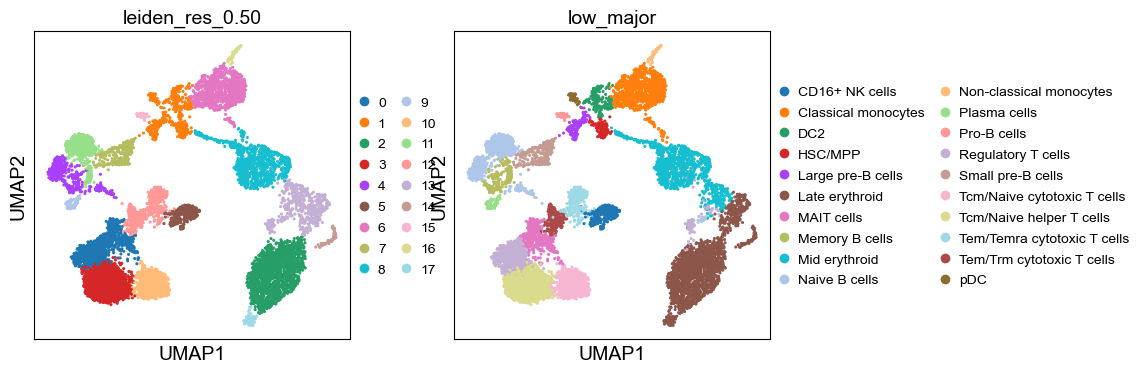

In [163]:
sc.pl.umap(adata, 
           color = ["leiden_res_0.50", 'low_major'], 
           s = 20)


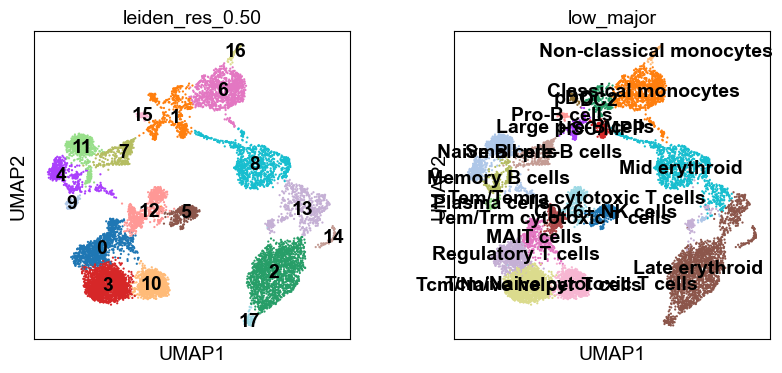

In [164]:
sc.pl.umap(
    adata=adata,
    color=["leiden_res_0.50", 'low_major'],
    ncols=2,
    legend_loc="on data",
)